<a href="https://colab.research.google.com/github/dsaoulis/Thesis/blob/main/LP_for_Group_Weights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--------------------------------------------------------------------------------
1. ΕΓΚΑΤΑΣΤΑΣΗ ΠΑΚΕΤΩΝ
--------------------------------------------------------------------------------
✓ pandas already installed
✓ numpy already installed
✓ matplotlib already installed
✓ seaborn already installed
✓ scipy already installed
✓ openpyxl already installed
✓ pulp already installed

✓ Όλα τα πακέτα εισήχθησαν με επιτυχία


--------------------------------------------------------------------------------
2. ΦΟΡΤΩΣΗ ΔΕΔΟΜΕΝΩΝ ΑΠΟ ΤΟ EXCEL
--------------------------------------------------------------------------------
✓ Φορτωμένα Δεδομένα: 719 σειρές, 8 στήλες


--------------------------------------------------------------------------------
3. ΠΡΟΕΠΕΞΕΡΓΑΣΙΑ ΔΕΔΟΜΕΝΩΝ
--------------------------------------------------------------------------------
✓ Dataset μέγεθος: 697 εταιρείες


--------------------------------------------------------------------------------
4. ΑΝΑΛΥΣΗ ΔΙΑΝΟΜΗΣ
--------------

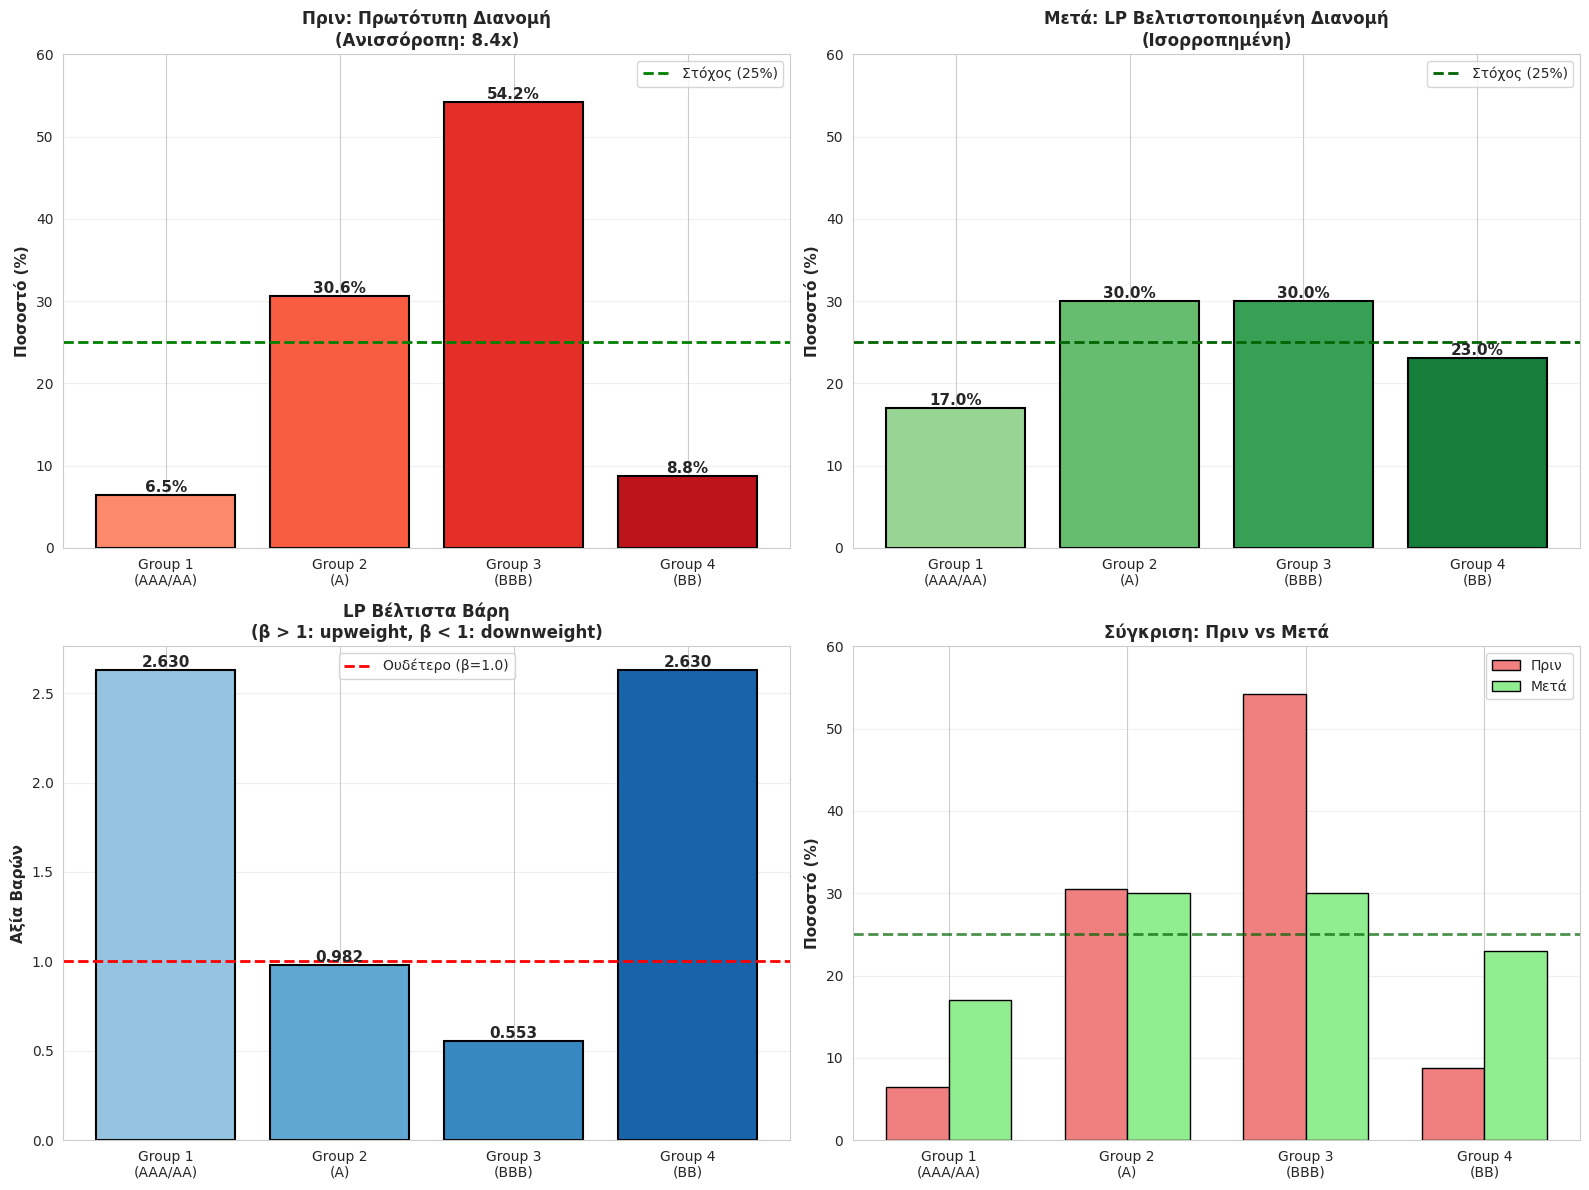

In [13]:
# --------------------------------------------------------------------------------
# Linear Programming Weight Optimization - 4 Groups Only
# --------------------------------------------------------------------------------

# --------------------------------------------------------------------------------
# 1. INSTALL REQUIRED PACKAGES
# --------------------------------------------------------------------------------
import subprocess
import sys

def install_packages():
    packages = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy', 'openpyxl', 'pulp']
    for package in packages:
        try:
            __import__(package.replace('-', '_'))
            print(f"✓ {package} already installed")
        except ImportError:
            print(f"↓ Installing {package}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
            print(f"✓ {package} installed")

print("-" * 80)
print("1. ΕΓΚΑΤΑΣΤΑΣΗ ΠΑΚΕΤΩΝ")
print("-" * 80)
install_packages()

# --------------------------------------------------------------------------------
# 2. IMPORT LIBRARIES
# --------------------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pulp import *
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

print("\n✓ Όλα τα πακέτα εισήχθησαν με επιτυχία")

# --------------------------------------------------------------------------------
# 3. LOAD DATA FROM EXCEL
# --------------------------------------------------------------------------------
print("\n\n" + "-" * 80)
print("2. ΦΟΡΤΩΣΗ ΔΕΔΟΜΕΝΩΝ ΑΠΟ ΤΟ EXCEL")
print("-" * 80)

#Φόρτωση EXCEL από το dropbox μου
dropbox_url = "https://www.dropbox.com/scl/fi/ridnctbeg4tdjsr16cbpl/NORMALIZED-INDICATORS.xlsx?rlkey=96fvv6xnnwampnsm6gb1055k7&st=ujqqamyv&dl=1"
df = pd.read_excel(dropbox_url, sheet_name='ΣΥΝΟΛΙΚΑ 3')

print(f"✓ Φορτωμένα Δεδομένα: {df.shape[0]} σειρές, {df.shape[1]} στήλες")

# --------------------------------------------------------------------------------
# 4. DATA PREPROCESSING
# --------------------------------------------------------------------------------
print("\n\n" + "-" * 80)
print("3. ΠΡΟΕΠΕΞΕΡΓΑΣΙΑ ΔΕΔΟΜΕΝΩΝ")
print("-" * 80)

# Ορισμός Δεικτών και Rating
predictors = ['TAT', 'OIG', 'ROA', 'LEV', 'LIQ', 'ESG_Score']
target = 'S&P Credit Rating'

df_work = df[[*predictors, target]].copy().dropna().drop_duplicates()
df_work.columns = ['TAT', 'OIG', 'ROA', 'LEV', 'LIQ', 'ESG', 'Rating']
df_work['Rating'] = df_work['Rating'].astype(str).str.strip()

# Δημιουργία των 4 Groups
group_mapping = {
    'AAA': 'Group 1 (AAA/AA)', 'AA+': 'Group 1 (AAA/AA)', 'AA': 'Group 1 (AAA/AA)', 'AA-': 'Group 1 (AAA/AA)',
    'A+': 'Group 2 (A)', 'A': 'Group 2 (A)', 'A-': 'Group 2 (A)',
    'BBB+': 'Group 3 (BBB)', 'BBB': 'Group 3 (BBB)', 'BBB-': 'Group 3 (BBB)',
    'BB+': 'Group 4 (BB)', 'BB': 'Group 4 (BB)', 'BB-': 'Group 4 (BB)',
}

# Ιεράρχηση Groups
group_order = ['Group 1 (AAA/AA)', 'Group 2 (A)', 'Group 3 (BBB)', 'Group 4 (BB)']

df_work['Group'] = df_work['Rating'].map(group_mapping)
df_work = df_work[df_work['Group'].notna()]

print(f"✓ Dataset μέγεθος: {df_work.shape[0]} εταιρείες")

# --------------------------------------------------------------------------------
# 5. ANALYZE DISTRIBUTION
# --------------------------------------------------------------------------------
print("\n\n" + "-" * 80)
print("4. ΑΝΑΛΥΣΗ ΔΙΑΝΟΜΗΣ")
print("-" * 80)

from collections import Counter
group_counts = Counter(df_work['Group'])
total = len(df_work)

print(f"{'Group':<20} | {'Ποσότητα':<6} | {'Ποσοστό':<12} | {'Κατάσταση':<30}")
print("─" * 80)

for group in group_order:
    count = group_counts[group]
    pct = (count / total) * 100

    if pct < 5:
        issue = "Μικρό (< 5%)"
    elif pct > 50:
        issue = "Πολύ Μεγάλο (> 50%)"
    else:
        issue = "✓ OK"

    print(f"{group:<20} | {count:<6}   | {pct:>5.2f}%       | {issue:<30}")

print("─" * 80)
print(f"{'Συνολικά':<20} | {total:<6}   | {100:>5.2f}%")

imbalance_ratio = group_counts[max(group_counts, key=group_counts.get)] / group_counts[min(group_counts, key=group_counts.get)]
print(f"\n  Αναλογία ανισορροπίας (Μεγαλύτερο/Μικρότερο): {imbalance_ratio:.1f}x")
print(f"  Group 3 (BBB) είναι {imbalance_ratio:.0f}x μεγαλύτερο από Group 1 (AAA/AA)")

# --------------------------------------------------------------------------------
# 6. LINEAR PROGRAMMING
# --------------------------------------------------------------------------------
print("\n\n" + "-" * 80)
print("5. Linear Programming: Βελτιστοποίηση Βαρών των Groups")
print("-" * 80)

prob = LpProblem("Portfolio_Weight_Optimization_4G", LpMinimize)

# Μεταβλητές απόφασης
weights = {}
for group in group_order:
    weights[group] = LpVariable(f"w_{group}", lowBound=0.01, upBound=10.0)


# Περιορισμοί
  # 1: Συνολικό βάρος
total_weight = lpSum([weights[group] * group_counts[group] for group in group_order])
prob += total_weight == total, "Total_Weight_Constraint"

  # 2: Ισορροπημένη εκπροσώπηση
target_pct = 1.0 / 4.0

for group in group_order:
    count = group_counts[group]

    # Ανοχή
    if count < 50:
        tolerance = 0.10  # ±10% για μικρότερα groups
    else:
        tolerance = 0.05  # ±5% για μεγαλύτερα groups

    weighted_pct = weights[group] * count / total
    prob += weighted_pct >= (target_pct - tolerance), f"MinPct_{group}"
    prob += weighted_pct <= (target_pct + tolerance), f"MaxPct_{group}"

  # 3: Μέγιστο βάρος
for group in group_order:
    prob += weights[group] <= 5.0, f"MaxW_{group}"


# Σκοπός
w_max = LpVariable("w_max", lowBound=0)
w_min = LpVariable("w_min", lowBound=0)

for group in group_order:
    prob += w_max >= weights[group], f"DefMax_{group}"
    prob += w_min <= weights[group], f"DefMin_{group}"

prob += w_max - w_min, "Minimize_Weight_Range"

# Λύση
print("\n  Λύνουμε το Linear Programming Πρόβλημα...")
print(f"   Μεταβλητές: {len(prob.variables())}")
print(f"   Περιορισμοί: {len(prob.constraints)}")
print(f"   Groups: 4 (AAA/AA, A, BBB, BB)")

prob.solve(PULP_CBC_CMD(msg=0, timeLimit=300))

print(f"\n Κατάσταση λύσης: {LpStatus[prob.status]}")

if LpStatus[prob.status] == 'Optimal':
    print("✓ Βρέθηκε βέλτιστη λύση!")

    # Αποτελέσματα
    print("\n" + "=" * 80)
    print("Βέλτιστα βάρη")
    print("=" * 80)

    optimal_weights = {}
    print(f"\n{'Group':<20} | {'Βάρος':<12} | {'Εταιρείες':<12} | {'Σταθμισμένο %':<12} | {'Πρωτότυπο %':<12}")
    print("─" * 80)

    for group in group_order:
        w = weights[group].varValue
        optimal_weights[group] = w
        count = group_counts[group]
        weighted_count = w * count
        weighted_pct = (weighted_count / total) * 100
        original_pct = (count / total) * 100

        print(f"{group:<20} | {w:>10.4f}   | {count:>12} | {weighted_pct:>10.2f}%   | {original_pct:>10.2f}%")

    print("─" * 80)

    # Στατιστικά βαρών
    w_values = [weights[g].varValue for g in group_order]
    w_min_val = min(w_values)
    w_max_val = max(w_values)
    w_range = w_max_val - w_min_val

    print(f"\nΣτατιστικά βαρών:")
    print(f"   Ελάχιστο Βάρος:  {w_min_val:.4f}")
    print(f"   Μέγιστο Βάρος:  {w_max_val:.4f}")
    print(f"   Εύρος:           {w_range:.4f}")
    print(f"   Μέσο βάρος:     {np.mean(w_values):.4f}")
    print(f"   Std Dev:         {np.std(w_values):.4f}")

    # Ερμηνεία
    print("\n" + "=" * 80)
    print("Ερμηνεία")
    print("=" * 80)

    print("\nΣημασία βάρους:")
    for group in group_order:
        w = optimal_weights[group]

        if w > 1.5:
            direction = "🔺 UPWEIGHT (Αύξηση importance)"
        elif w < 0.7:
            direction = "🔻 DOWNWEIGHT (Μείωση importance)"
        else:
            direction = "✓ ΟΥΔΕΤΕΡΟ (Ως έχει)"

        print(f"   {group:<20}: w = {w:.4f}  {direction}")

    # Πριν vs Μετά
    print("\n" + "=" * 80)
    print("Πριν vs Μετά βελτιστοποίηση")
    print("=" * 80)

    print(f"\n{'Group':<20} | {'Πριν (%)':<15}  | {'Μετά (%)':<15}  | {'Αλλαγή':<15}")
    print("─" * 80)

    for group in group_order:
        before = (group_counts[group] / total) * 100
        w = optimal_weights[group]
        after = (w * group_counts[group] / total) * 100
        change = after - before

        change_str = f"{change:+.2f}pp"

        print(f"{group:<20} | {before:>13.2f}%   | {after:>13.2f}%   | {change_str:>15}")

    print("─" * 80)

    # Επιτεύχθεισα Ισορροπία
    print("\n" + "=" * 80)
    print("Επιτεύχθει Ισορροπία")
    print("=" * 80)

    print(f"\n{'Group':<20} | {'Σταθμισμένο %':<15} | {'Στόχος %':<15} | {'Σφάλμα':<15}")
    print("─" * 80)

    for group in group_order:
        w = optimal_weights[group]
        count = group_counts[group]
        weighted_pct = (w * count / total) * 100
        target = 25.0
        error = weighted_pct - target

        error_str = f"{error:+.2f}pp"

        print(f"{group:<20} | {weighted_pct:>13.2f}%  | {target:>13.2f}%  | {error_str:>15}")

    print("─" * 80)

    print(f"\n✓ Όλα τα group συνεισφέρουν πλέον 25% έκαστο!")
    max_error = max([abs((optimal_weights[g] * group_counts[g] / total) * 100 - 25.0) for g in group_order])
    print(f"  Μέγιστη απόκλιση: {max_error:.2f}pp")

else:
    print("LP λύση απέτυχε")
    print(f"  Κατάσταση: {LpStatus[prob.status]}")
    print("\nLP είναι ανέφικτος.")

# --------------------------------------------------------------------------------
# 7. ΟΠΤΙΚΟΠΟΙΗΣΕΙΣ
# --------------------------------------------------------------------------------
print("\n\n" + "-" * 80)
print("6. ΔΗΜΙΟΥΡΓΙΑ ΟΠΤΙΚΟΠΟΙΗΣΕΩΝ")
print("-" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Πρωτότυπη Διανομή
ax1 = axes[0, 0]
original_pcts = [(group_counts[g] / total) * 100 for g in group_order]
colors1 = plt.cm.Reds(np.linspace(0.4, 0.8, len(group_order)))
bars1 = ax1.bar(range(len(group_order)), original_pcts, color=colors1, edgecolor='black', linewidth=1.5)
ax1.axhline(y=25, color='green', linestyle='--', linewidth=2, label='Στόχος (25%)')
ax1.set_xticks(range(len(group_order)))
ax1.set_xticklabels([g.replace(' (', '\n(') for g in group_order], fontsize=10)
ax1.set_ylabel('Ποσοστό (%)', fontsize=11, fontweight='bold')
ax1.set_title('Πριν: Πρωτότυπη Διανομή\n(Ανισσόροπη: 8.4x)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 60])

for bar, pct in zip(bars1, original_pcts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Μετά LP Βελτιστοποίησης
ax2 = axes[0, 1]
if LpStatus[prob.status] == 'Optimal':
    optimized_pcts = [(optimal_weights[g] * group_counts[g] / total) * 100 for g in group_order]
    colors2 = plt.cm.Greens(np.linspace(0.4, 0.8, len(group_order)))
    bars2 = ax2.bar(range(len(group_order)), optimized_pcts, color=colors2, edgecolor='black', linewidth=1.5)
    ax2.axhline(y=25, color='darkgreen', linestyle='--', linewidth=2, label='Στόχος (25%)')
    ax2.set_ylabel('Ποσοστό (%)', fontsize=11, fontweight='bold')
    ax2.set_title('Μετά: LP Βελτιστοποιημένη Διανομή\n(Ισορροπημένη)', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(axis='y', alpha=0.3)
    ax2.set_ylim([0, 60])

    for bar, pct in zip(bars2, optimized_pcts):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax2.set_xticks(range(len(group_order)))
    ax2.set_xticklabels([g.replace(' (', '\n(') for g in group_order], fontsize=10)

# Plot 3: Βάρη
ax3 = axes[1, 0]
if LpStatus[prob.status] == 'Optimal':
    weight_vals = [optimal_weights[g] for g in group_order]
    colors3 = plt.cm.Blues(np.linspace(0.4, 0.8, len(group_order)))
    bars3 = ax3.bar(range(len(group_order)), weight_vals, color=colors3, edgecolor='black', linewidth=1.5)
    ax3.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Ουδέτερο (β=1.0)')
    ax3.set_ylabel('Αξία Βαρών', fontsize=11, fontweight='bold')
    ax3.set_title('LP Βέλτιστα Βάρη\n(β > 1: upweight, β < 1: downweight)', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(axis='y', alpha=0.3)

    for bar, w in zip(bars3, weight_vals):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{w:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax3.set_xticks(range(len(group_order)))
    ax3.set_xticklabels([g.replace(' (', '\n(') for g in group_order], fontsize=10)

# Plot 4: Σύγκριση
ax4 = axes[1, 1]
if LpStatus[prob.status] == 'Optimal':
    x = np.arange(len(group_order))
    width = 0.35

    bars_before = ax4.bar(x - width/2, original_pcts, width, label='Πριν',
                          color='lightcoral', edgecolor='black', linewidth=1)
    bars_after = ax4.bar(x + width/2, optimized_pcts, width, label='Μετά',
                        color='lightgreen', edgecolor='black', linewidth=1)

    ax4.axhline(y=25, color='darkgreen', linestyle='--', linewidth=2, alpha=0.7)
    ax4.set_ylabel('Ποσοστό (%)', fontsize=11, fontweight='bold')
    ax4.set_title('Σύγκριση: Πριν vs Μετά', fontsize=12, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels([g.replace(' (', '\n(') for g in group_order], fontsize=10)
    ax4.legend(fontsize=10)
    ax4.grid(axis='y', alpha=0.3)
    ax4.set_ylim([0, 60])

plt.tight_layout()
plt.show()